In [ ]:

import os
import json

import pandas as pd
from tqdm import tqdm
import torch

from langchain.docstore.document import Document as LangchainDocument
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

from langchain_community.llms import HuggingFaceHub
from transformers import AutoModel, AutoTokenizer
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.retrievers import BM25Retriever
from langchain.retrievers import EnsembleRetriever

from langchain_chroma import Chroma
from langchain_community.document_loaders import (
    DirectoryLoader,
    UnstructuredMarkdownLoader,
)
from lib.clients.llm import SimpleLLMFactory
from lib.models.embedder import Embedder

from dotenv import load_dotenv
import matplotlib.pyplot as plt

from huggingface_hub import login
load_dotenv()

In [ ]:
embedder = Embedder()  # можно передать model_name="..." при желании
embeddings = embedder.embeddings  # это HuggingFaceEmbeddings из LangChain

factory = SimpleLLMFactory(temperature=0)
gpt_oss_120b = factory.create("openai/gpt-oss-120b")

# вместо этого нужно заменить на lib/models/reranker.py и переписать чуть код ниже

# xprovence_tokenizer = AutoTokenizer.from_pretrained("naver/xprovence-reranker-bgem3-v1", trust_remote_code=True)
# xprovence_model = AutoModel.from_pretrained("naver/xprovence-reranker-bgem3-v1", trust_remote_code=True)



NameError: name 'load_dotenv' is not defined

In [4]:
# ========== Загрузка и подготовка документов ==========
def load_knowledge_base(dir_path: str) -> List[LangchainDocument]:
    """Загружает markdown‑файлы из каталога как LangChain‑документы."""
    loader = DirectoryLoader(
        dir_path, glob="**/*.md", loader_cls=UnstructuredMarkdownLoader
    )
    docs = loader.load()
    return docs


def split_documents(
    docs: List[LangchainDocument],
    chunk_size: int,
    tokenizer_name: str,
) -> List[LangchainDocument]:
    """Делит документы на чанки фиксированного размера в токенах."""
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        tokenizer,
        chunk_size=chunk_size,
        chunk_overlap=int(chunk_size * 0.1),
        add_start_index=True,
        strip_whitespace=True,
        separators=["\n\n", "\n", ".", " ", ""],
    )
    processed = []
    for doc in docs:
        processed += splitter.split_documents([doc])
    # убираем дубликаты по содержимому
    seen = set()
    unique_docs = []
    for doc in processed:
        if doc.page_content not in seen:
            seen.add(doc.page_content)
            unique_docs.append(doc)
    return unique_docs

In [5]:
# ========== Инициализация эмбеддингов ==========
def init_embedding_model(model_id: str):
    """Создаёт объект HuggingFaceEmbeddings, используя заранее загруженные модели."""
    # Пользователь загружает модели через AutoTokenizer/AutoModel отдельно:
    # bge_tokenizer = AutoTokenizer.from_pretrained("deepvk/USER-bge-m3")
    # bge_model = AutoModel.from_pretrained("deepvk/USER-bge-m3")
    embedding_model = HuggingFaceEmbeddings(
        model_name=model_id,
        model_kwargs={"device": "cuda" if torch.cuda.is_available() else "cpu"},
        encode_kwargs={"normalize_embeddings": True},
    )
    return embedding_model

In [16]:
# ========== Построение Chroma и BM25 ==========
def build_chroma(processed_docs, embedding_model, persist_dir, collection_name):
    """
    Создаёт или загружает Chroma. При создании новой коллекции embedding_model
    передаётся позиционно как embedding, чтобы избежать дублирования параметра.
    """
    os.makedirs(persist_dir, exist_ok=True)
    store_path = os.path.join(persist_dir, collection_name)
    if os.path.exists(store_path):
        # загружаем существующую коллекцию
        return Chroma(
            collection_name=collection_name,
            persist_directory=persist_dir,
            embedding_function=embedding_model,
        )
    # создаём новую коллекцию: embedding_model передаём позиционно
    return Chroma.from_documents(
        processed_docs,
        embedding_model,   # этот аргумент соответствует параметру `embedding`
        collection_name=collection_name,
        persist_directory=persist_dir,
    )

def build_bm25(docs):
    return BM25Retriever.from_documents(docs)

In [17]:
# ---------- 4. Создание ансамблевого ретривера ----------
def build_ensemble_retriever(chroma_db: Chroma, bm25: BM25Retriever):
    """
    Создаёт MMR‑ретривер на основе Chroma и ансамбль MMR+BM25.
    search_kwargs: k – сколько документов вернуть в результате,
    fetch_k – сколько изначально выбрать для MMR (до переупорядочивания),
    lambda_mult – параметр баланса релевантность/разнообразие.
    """
    mmr = chroma_db.as_retriever(
        search_type="mmr",
        search_kwargs={"k": 6, "fetch_k": 40, "lambda_mult": 0.5},
    )
    ensemble = EnsembleRetriever(
        retrievers=[mmr, bm25],
        weights=[0.6, 0.4],
    )
    return ensemble

In [28]:
## ---------- 5. Функция ответа RAG ----------
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

def answer_with_rag(
    question: str,
    llm_reader,
    ensemble_retriever: EnsembleRetriever,
    xprovence_model=None,
    top_k: int = 7,
):
    # получаем релевантные контексты (как раньше) ...
    docs = ensemble_retriever.get_relevant_documents(question)
    contexts = [d.page_content for d in docs][:top_k]
    # при необходимости используем XProvence (как обсуждалось ранее)
    if xprovence_model:
        output = xprovence_model.process([question], [contexts], reorder=True, top_k=len(contexts))
        contexts = output.get("pruned_context", [contexts])[0]

    # формируем текст подсказки
    context_block = "\n\n".join([f"Document {i}:\n{ctx}" for i, ctx in enumerate(contexts)])
    prompt_text = (
        "Используя информацию из контекста, дайте краткий и точный ответ на вопрос. "
        "Если ответ нельзя вывести, ответьте 'Не знаю'.\n\n"
        f"Контекст:\n{context_block}\n\nВопрос: {question}"
    )

    # Проверяем, является ли модель чат‑моделью. Если да — используем HumanMessage.
    if hasattr(llm_reader, "invoke"):
        # для ChatModel: оборачиваем текст в HumanMessage и вызываем invoke
        messages = [HumanMessage(content=prompt_text)]
        reply = llm_reader.invoke(messages)
        # reply — объект BaseMessage; извлекаем текст ответа
        answer = reply.content if hasattr(reply, "content") else str(reply)
    else:
        # для обычных LLM: передаём строку как есть
        answer = llm_reader(prompt_text)

    return answer, contexts

In [29]:
# ---------- 6. Запуск экспериментов ----------
def run_rag_experiment(
    eval_dataset,
    ensemble_retriever: EnsembleRetriever,
    llm_reader,
    xprovence_model=None,
):
    results = []
    for sample in tqdm(eval_dataset, desc="Evaluating"):
        q = sample["question"]
        a_true = sample["answer"]
        a_gen, ctxs = answer_with_rag(
            question=q,
            llm_reader=llm_reader,
            ensemble_retriever=ensemble_retriever,
            xprovence_model=xprovence_model,
        )
        results.append(
            {
                "question": q,
                "true_answer": a_true,
                "generated_answer": a_gen,
                "contexts": ctxs,
            }
        )
    return results


def evaluate_configs(
    eval_dataset,
    knowledge_dir: str,
    chunk_sizes: List[int],
    embedding_models: List[str],
    use_xprovence: List[bool],
    llm_reader,
    output_dir: str,
):
    """
    Запускает испытания для комбинаций:
    - chunk_size
    - embedding_model
    - использование XProvence (True/False)
    Все результаты сохраняются в файлы JSON.
    """
    raw_docs = load_knowledge_base(knowledge_dir)

    # Загружаем XProvence один раз
    xprovence_model = None

    for chunk_size in chunk_sizes:
        for embed_id in embedding_models:
            # деление на чанки и инициализация эмбеддингов
            processed = split_documents(raw_docs, chunk_size, tokenizer_name=embed_id)
            embedding_model = init_embedding_model(embed_id)
            chroma_db = build_chroma(
                processed,
                embedding_model,
                persist_dir="/Users/sergey/Desktop/LangGraph-DIY-car-agent/Data/ChromaDB",
                collection_name=f"chunk{chunk_size}_{embed_id.replace('/', '_')}",
            )
            bm25_retriever = build_bm25(processed)
            ensemble_ret = build_ensemble_retriever(chroma_db, bm25_retriever)

            for prune_flag in use_xprovence:
                # загружаем XProvence при первом использовании
                if prune_flag and xprovence_model is None:
                    # инициализируем модель при первом использовании
                    xprovence_tokenizer = AutoTokenizer.from_pretrained(
                        "naver/xprovence-reranker-bgem3-v1",
                        trust_remote_code=True
                    )
                    xprovence_model = AutoModel.from_pretrained(
                        "naver/xprovence-reranker-bgem3-v1",
                        trust_remote_code=True
                    )

                config_name = (
                    f"chunk{chunk_size}_emb{embed_id.replace('/', '-')}_xprov{prune_flag}"
                )
                outputs = run_rag_experiment(
                    eval_dataset=eval_dataset,
                    ensemble_retriever=ensemble_ret,
                    llm_reader=llm_reader,
                    xprovence_model=xprovence_model if prune_flag else None,
                )
                os.makedirs(output_dir, exist_ok=True)
                with open(os.path.join(output_dir, f"{config_name}.json"), "w", encoding="utf-8") as f:
                    json.dump(outputs, f, ensure_ascii=False, indent=2)
                print(f"Конфигурация {config_name} завершена.")

In [30]:

def load_eval_dataset(csv_path: str, score_threshold: float = None):
    """
    Загружает CSV с колонками context, question, answer, source_doc,
    groundedness_score, relevance_score, standalone_score.
    
    Если указан threshold, оставляет только строки, где все три оценки ≥ threshold.
    """
    df = pd.read_csv(csv_path)
    if score_threshold is not None:
        mask = (
            (df["groundedness_score"] >= score_threshold)
            & (df["relevance_score"] >= score_threshold)
            & (df["standalone_score"] >= score_threshold)
        )
        df = df[mask].reset_index(drop=True)
    # возвращаем список словарей со столбцами question и answer
    return df[["question", "answer"]].to_dict(orient="records")

In [31]:
# --- пример загрузки данных для эвалюации ---
from pathlib import Path

# CSV содержит столбцы context, question, answer, source_doc, groundedness_score, relevance_score, standalone_score
eval_dataset = load_eval_dataset(
    csv_path=Path("/Users/sergey/Desktop/LangGraph-DIY-car-agent/Data/eval_dataset.csv"),
    score_threshold=4  # опционально фильтруем по оценкам критиков
)

In [ ]:
# --- запуск экспериментов ---
evaluate_configs(
    eval_dataset=eval_dataset,
    knowledge_dir="/Users/sergey/Desktop/LangGraph-DIY-car-agent/Data/cleaned",  # путь к папке с вашими Markdown‑документами
    chunk_sizes=[300, 600, 900, 1200 ],
    embedding_models=["deepvk/USER-bge-m3", "intfloat/multilingual-e5-base"],
    use_xprovence=[True, False],  # запускать или нет XProvence с reorder=True
    llm_reader=gpt_oss_120b,       # ваш LLM для генерации ответов
    output_dir="./Users/sergey/Desktop/LangGraph-DIY-car-agent/Data/result_eval"    # куда сохранять результаты
)

Ограничения этих метрик (важно понимать)

	1.	Это всё ещё лексические метрики

Они не понимают синонимы и перефразировки, которые сильно отличаются по словам.

	2.	Для длинных, развернутых ответов F1 и EM становятся хуже индикаторами — особенно если:
	•	много лишнего текста;
	•	или «правильный» ответ — короткий фрагмент, а модель пишет эссе.

	3.	Они не измеряют «логическую корректность».
    
Если модель напишет что-то вроде:
«Ответ: 42. Но на самом деле правильный ответ 17.»
— слова 42 и 17 есть, F1 может быть не ноль, хотя по смыслу ответ бредовый.

In [37]:
import json
import os
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "/Users/sergey/Desktop/LangGraph-DIY-car-agent/Data/result_eval"


# --------------------------------------------------
#                 МЕТРИКИ
# --------------------------------------------------

def normalize_answer(s: str) -> str:
    """Удаляем пунктуацию, приводим к нижнему регистру и убираем артикли."""
    def remove_articles(text):
        return re.sub(r"\b(a|an|the)\b", " ", text)
    def white_space_fix(text):
        return " ".join(text.split())
    def remove_punc(text):
        return re.sub(r"[^\w\s]", "", text)
    def lower(text): 
        return text.lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))


def exact_match(pred, truth):
    return normalize_answer(pred) == normalize_answer(truth)


def f1_score(pred, truth):
    pred_tokens = normalize_answer(pred).split()
    truth_tokens = normalize_answer(truth).split()
    common = Counter(pred_tokens) & Counter(truth_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(truth_tokens)
    return 2 * precision * recall / (precision + recall)


# --------------------------------------------------
#           Функция оценки одного файла
# --------------------------------------------------

def evaluate_file(path):
    with open(path, encoding="utf-8") as f:
        data = json.load(f)

    em_total, f1_total = 0, 0

    for row in data:
        em_total += exact_match(row["generated_answer"], row["true_answer"])
        f1_total += f1_score(row["generated_answer"], row["true_answer"])

    n = len(data)
    return {
        "EM": em_total / n,
        "F1": f1_total / n,
        "N": n
    }


# --------------------------------------------------
#       Сбор всех результатов в DataFrame
# --------------------------------------------------

records = []

for fname in os.listdir(RESULTS_DIR):
    if not fname.endswith(".json"):
        continue

    config_path = os.path.join(RESULTS_DIR, fname)
    scores = evaluate_file(config_path)

    # парсим название конфигурации
    # формат: chunk300_embdeepvk-USER-bge-m3_xprovTrue
    name = fname.replace(".json", "")
    parts = name.split("_")

    chunk = int(parts[0].replace("chunk", ""))

    emb = parts[1].replace("emb", "")
    xprov = parts[2].replace("xprov", "") == "True"

    records.append({
        "config": name,
        "chunk": chunk,
        "embedding": emb,
        "xprovence": xprov,
        **scores
    })

df = pd.DataFrame(records)
df

,config,chunk,embedding,xprovence,EM,F1,N
0,chunk900_embintfloat-multilingual-e5-base_xpro...,900,intfloat-multilingual-e5-base,True,0.188406,0.448710,69
1,chunk1200_embintfloat-multilingual-e5-base_xpr...,1200,intfloat-multilingual-e5-base,True,0.188406,0.476462,69
2,chunk300_embdeepvk-USER-bge-m3_xprovTrue,300,deepvk-USER-bge-m3,True,0.231884,0.513347,69
3,chunk1200_embintfloat-multilingual-e5-base_xpr...,1200,intfloat-multilingual-e5-base,False,0.115942,0.411216,69
4,chunk600_embdeepvk-USER-bge-m3_xprovTrue,600,deepvk-USER-bge-m3,True,0.275362,0.503577,69
5,chunk900_embdeepvk-USER-bge-m3_xprovTrue,900,deepvk-USER-bge-m3,True,0.217391,0.482794,69
6,chunk1200_embdeepvk-USER-bge-m3_xprovFalse,1200,deepvk-USER-bge-m3,False,0.173913,0.478548,69
7,chunk600_embintfloat-multilingual-e5-base_xpro...,600,intfloat-multilingual-e5-base,False,0.202899,0.467927,69
8,chunk600_embintfloat-multilingual-e5-base_xpro...,600,intfloat-multilingual-e5-base,True,0.217391,0.486976,69
9,chunk300_embintfloat-multilingual-e5-base_xpro...,300,intfloat-multilingual-e5-base,True,0.289855,0.557104,69


id: 03e0c556-48a9-464d-8abc-5cb4107bdf20 name: chunk1200_deepvk_USER-bge-m3 metadata: None

id: 0a748335-aeb3-46f7-b5e5-8bcccd542f4c name: VectorDB_deepvk_USER-bge-m3 metadata: None

id: 0cd36446-e438-4626-b961-134572322793 name: chunk600_intfloat_multilingual-e5-base metadata: None

id: 33a9d05d-0955-4ad2-971f-5cabcaef71f5 name: chunk1200_intfloat_multilingual-e5-base metadata: None

id: 6453686e-76be-4791-ae31-876068dc1fde name: chunk900_deepvk_USER-bge-m3 metadata: None

id: aa4f8703-becd-43f1-a052-195eff72aa95 name: chunk300_intfloat_multilingual-e5-base metadata: None

id: b093b73b-ce91-4cda-8bb7-8e4e934a265d name: chunk600_deepvk_USER-bge-m3 metadata: None

id: d804cee8-1a0b-4997-ac1f-410fa51cb971 name: chunk900_intfloat_multilingual-e5-base metadata: None

id: f27211cb-01c4-4ff1-b64e-b4cc3a2ba9d2 name: chunk300_deepvk_USER-bge-m3 metadata: None


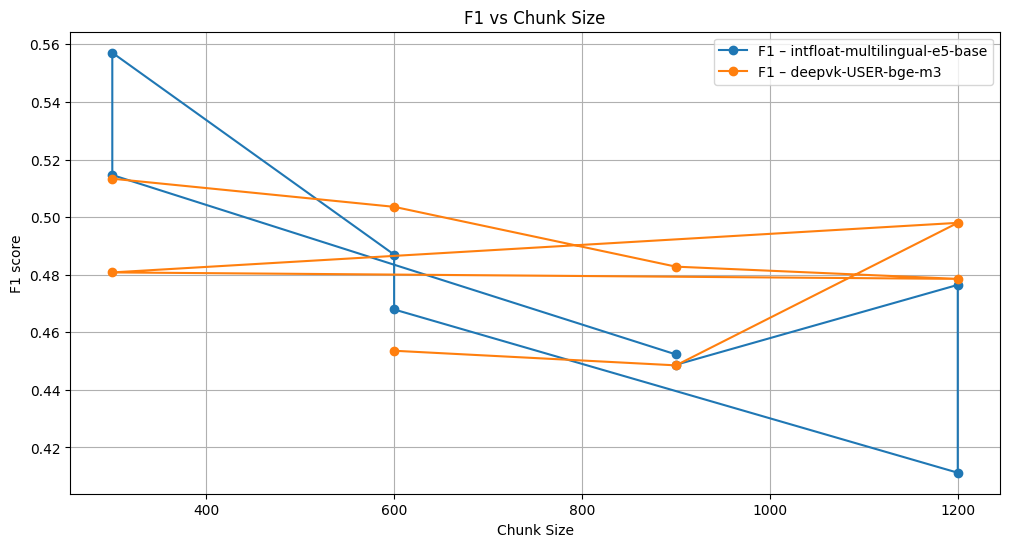

In [38]:
plt.figure(figsize=(12, 6))

for emb in df["embedding"].unique():
    subset = df[df["embedding"] == emb]
    plt.plot(subset["chunk"], subset["F1"], marker='o', label=f"F1 – {emb}")

plt.title("F1 vs Chunk Size")
plt.xlabel("Chunk Size")
plt.ylabel("F1 score")
plt.legend()
plt.grid()
plt.show()

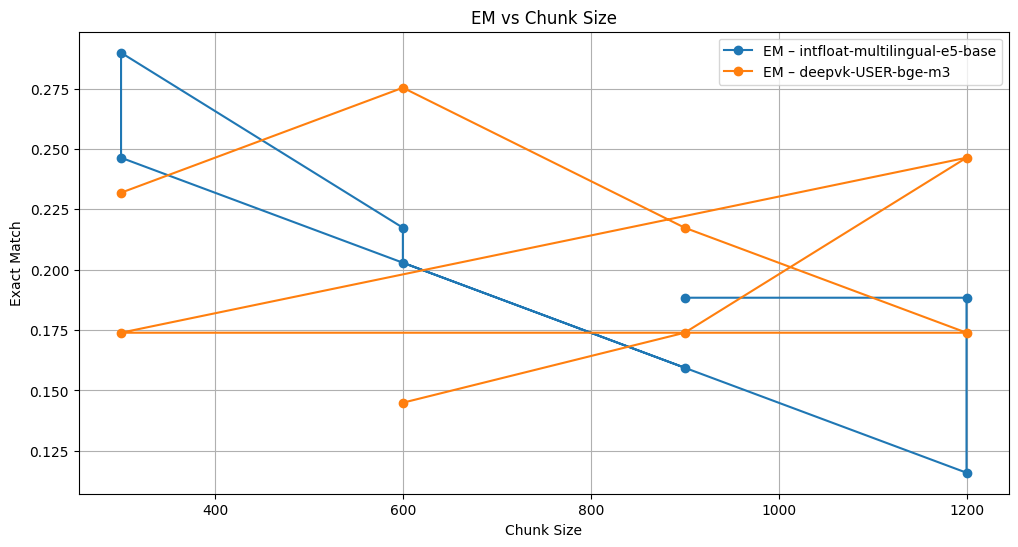

In [39]:
plt.figure(figsize=(12, 6))

for emb in df["embedding"].unique():
    subset = df[df["embedding"] == emb]
    plt.plot(subset["chunk"], subset["EM"], marker='o', label=f"EM – {emb}")

plt.title("EM vs Chunk Size")
plt.xlabel("Chunk Size")
plt.ylabel("Exact Match")
plt.legend()
plt.grid()
plt.show()

In [40]:
effect_rows = []

for emb in df["embedding"].unique():
    for chunk in df["chunk"].unique():

        base = df[(df.embedding == emb) & (df.chunk == chunk) & (df.xprovence == False)]
        xprov = df[(df.embedding == emb) & (df.chunk == chunk) & (df.xprovence == True)]

        if len(base) == 1 and len(xprov) == 1:
            effect_rows.append({
                "embedding": emb,
                "chunk": chunk,
                "F1_no_xp": base.iloc[0]["F1"],
                "F1_xp": xprov.iloc[0]["F1"],
                "F1_gain": xprov.iloc[0]["F1"] - base.iloc[0]["F1"],
                "EM_no_xp": base.iloc[0]["EM"],
                "EM_xp": xprov.iloc[0]["EM"],
                "EM_gain": xprov.iloc[0]["EM"] - base.iloc[0]["EM"],
            })

df_effect = pd.DataFrame(effect_rows)
df_effect

,embedding,chunk,F1_no_xp,F1_xp,F1_gain,EM_no_xp,EM_xp,EM_gain
0,intfloat-multilingual-e5-base,900,0.452304,0.448710,-0.003594,0.159420,0.188406,0.028986
1,intfloat-multilingual-e5-base,1200,0.411216,0.476462,0.065246,0.115942,0.188406,0.072464
2,intfloat-multilingual-e5-base,300,0.514629,0.557104,0.042475,0.246377,0.289855,0.043478
3,intfloat-multilingual-e5-base,600,0.467927,0.486976,0.019049,0.202899,0.217391,0.014493
4,deepvk-USER-bge-m3,900,0.448509,0.482794,0.034285,0.173913,0.217391,0.043478
5,deepvk-USER-bge-m3,1200,0.478548,0.498012,0.019464,0.173913,0.246377,0.072464
6,deepvk-USER-bge-m3,300,0.480791,0.513347,0.032557,0.173913,0.231884,0.057971
7,deepvk-USER-bge-m3,600,0.453583,0.503577,0.049994,0.144928,0.275362,0.130435


In [41]:
best_f1 = df.iloc[df["F1"].idxmax()]
best_em = df.iloc[df["EM"].idxmax()]

print("Лучшая конфигурация по F1:\n", best_f1, "\n")
print("Лучшая конфигурация по EM:\n", best_em)

Лучшая конфигурация по F1:
 config       chunk300_embintfloat-multilingual-e5-base_xpro...
chunk                                                      300
embedding                        intfloat-multilingual-e5-base
xprovence                                                 True
EM                                                    0.289855
F1                                                    0.557104
N                                                           69
Name: 9, dtype: object 

Лучшая конфигурация по EM:
 config       chunk300_embintfloat-multilingual-e5-base_xpro...
chunk                                                      300
embedding                        intfloat-multilingual-e5-base
xprovence                                                 True
EM                                                    0.289855
F1                                                    0.557104
N                                                           69
Name: 9, dtype: object


В ноутбуке OpenAI применяется «семантический судья» — GPT-4, который оценивает:

	•	Correctness (насколько ответ действительно правильный)

	•	Groundedness (насколько опирается на данные из контекста)

	•	Relevance
	
	•	Completeness

То есть модель читает вопрос, правильный ответ, сгенерированный ответ и контекст — и решает, насколько ответ корректен по смыслу, а не по словам.

In [56]:
# ------------------ PROMPT ------------------

JUDGE_PROMPT = """
Вы — строгая оценочная модель. Ваша задача — оценить качество ответа модели,
используя вопрос, эталонный (правильный) ответ и полученный контекст.

Оцените каждый критерий по шкале от 0 до 5.

### Вопрос:
{question}

### Эталонный ответ:
{true_answer}

### Ответ модели:
{generated_answer}

### Извлечённый контекст:
{contexts}

Теперь оцените ответ модели по следующим критериям:

1. Correctness (Корректность) — является ли ответ фактически правильным.
2. Groundedness (Опора на контекст) — подтверждается ли ответ предоставленным контекстом.
3. Relevance (Релевантность) — насколько ответ соответствует поставленному вопросу.
4. Coherence (Связанность) — насколько ответ ясен, логичен и структурирован.

Ответьте строго в формате JSON:
{{
  "correctness": <0-5>,
  "groundedness": <0-5>,
  "relevance": <0-5>,
  "coherence": <0-5>,
  "explanation": "<краткое объяснение>"
}}
"""

🧠 Функция-оценщик (для одной пары)

In [57]:
# ------------------ ОЦЕНКА ОДНОГО ПРИМЕРА ------------------

def judge_answer(llm, question, true_answer, generated_answer, contexts):
    prompt = JUDGE_PROMPT.format(
        question=question,
        true_answer=true_answer,
        generated_answer=generated_answer,
        contexts="\n\n".join(contexts)
    )

    reply = llm.invoke([HumanMessage(content=prompt)])
    text = reply.content.strip()

    try:
        return json.loads(text)
    except:
        # Попытка извлечь JSON, если модель вернула лишний текст
        try:
            json_part = text[text.index("{"): text.rindex("}")+1]
            return json.loads(json_part)
        except:
            return {
                "correctness": None,
                "groundedness": None,
                "relevance": None,
                "coherence": None,
                "explanation": text
            }

🔄 Оценка всех примеров в конфигурации

In [58]:
# ------------------ ОЦЕНКА ВСЕГО JSON-ФАЙЛА ------------------

def llm_judge_experiment(llm, results_json_path):
    with open(results_json_path, encoding="utf-8") as f:
        data = json.load(f)

    judged = []

    for item in tqdm(data):
        j = judge_answer(
            llm=llm,
            question=item["question"],
            true_answer=item["true_answer"],
            generated_answer=item["generated_answer"],
            contexts=item["contexts"]
        )
        judged.append(j)

    return judged

📊 Усреднение всех показателей

In [59]:
# ------------------ АГРЕГАЦИЯ РЕЗУЛЬТАТОВ ------------------

def summarize_judgements(judged_list):
    df = pd.DataFrame(judged_list)

    return {
        "correctness_avg": df["correctness"].mean(),
        "groundedness_avg": df["groundedness"].mean(),
        "relevance_avg": df["relevance"].mean(),
        "coherence_avg": df["coherence"].mean(),
    }

In [60]:
# ------------------ ГЛАВНАЯ ФУНКЦИЯ ------------------

def evaluate_all_configs(result_dir, llm):
    summary_rows = []

    for fname in os.listdir(result_dir):
        if not fname.endswith(".json"):
            continue

        config_name = fname.replace(".json", "")
        json_path = os.path.join(result_dir, fname)

        judged = llm_judge_experiment(llm, json_path)
        summary = summarize_judgements(judged)
        summary["config"] = config_name

        summary_rows.append(summary)

    summary_df = pd.DataFrame(summary_rows)
    summary_df = summary_df[
        ["config", "correctness_avg", "groundedness_avg", "relevance_avg", "coherence_avg"]
    ]

    summary_df.to_csv("judge_summary.csv", index=False)
    return summary_df

In [61]:

# ------------------ ЗАПУСК ------------------

summary_df = evaluate_all_configs(
    result_dir="/Users/sergey/Desktop/LangGraph-DIY-car-agent/Data/result_eval",
    llm=gpt_oss_120b
)

summary_df

100%|██████████| 69/69 [03:45<00:00,  3.27s/it]


,config,correctness_avg,groundedness_avg,relevance_avg,coherence_avg
0,chunk900_embintfloat-multilingual-e5-base_xpro...,3.811594,4.231884,4.289855,4.739130
1,chunk1200_embintfloat-multilingual-e5-base_xpr...,3.956522,4.449275,4.391304,4.797101
2,chunk300_embdeepvk-USER-bge-m3_xprovTrue,4.318841,4.753623,4.782609,4.942029
3,chunk1200_embintfloat-multilingual-e5-base_xpr...,4.220588,4.676471,4.691176,4.852941
4,chunk600_embdeepvk-USER-bge-m3_xprovTrue,4.043478,4.405797,4.405797,4.782609
5,chunk900_embdeepvk-USER-bge-m3_xprovTrue,4.028986,4.550725,4.391304,4.855072
6,chunk1200_embdeepvk-USER-bge-m3_xprovFalse,4.347826,4.521739,4.594203,4.811594
7,chunk600_embintfloat-multilingual-e5-base_xpro...,4.000000,4.318841,4.478261,4.884058
8,chunk600_embintfloat-multilingual-e5-base_xpro...,3.869565,4.333333,4.420290,4.840580
9,chunk300_embintfloat-multilingual-e5-base_xpro...,4.279412,4.588235,4.647059,4.911765
